In [1]:
import numpy as np

from factors import *

In [2]:
bt = BackTester(fc_name_list=['fac_cumret', 'fac_upperline', 'fac_winrate'],
                instrument_type='futures_continuous_contract',
                instrument_id_list = ['C0', 'FG0'],
                fc_freq = '1d',
                start_time='20230101',
                end_time='20260310',
                portfolio_adjust_method = '1D',
                interest_method = 'compound',
                risk_free_rate=False,
                n_jobs = 5
                )
# bt.backtest()

In [3]:
bt.data

,time,instrument_id,open,high,low,close,volume,position
0,2023-01-03,C0,2829,2842,2817,2840,301325,705314
1,2023-01-04,C0,2840,2877,2838,2875,489218,711148
2,2023-01-05,C0,2875,2882,2859,2878,341944,714472
3,2023-01-06,C0,2873,2892,2867,2886,368002,731213
4,2023-01-09,C0,2882,2895,2879,2890,306730,744645
...,...,...,...,...,...,...,...,...
1531,2026-03-04,FG0,1055,1055,1037,1038,985426,1321021
1532,2026-03-05,FG0,1039,1065,1038,1055,1177512,1263360
1533,2026-03-06,FG0,1056,1093,1052,1087,1384174,1256461
1534,2026-03-09,FG0,1098,1163,1090,1104,3221862,1165149


In [4]:
# self = bt
# Data = self.data
# df = Data.copy()
#
# df = df.sort_values(by='time', ascending=True)
# df = df.set_index(['time', 'instrument_id'])
#
# fc_class_list = [resolve_factor_class(fc_name) for fc_name in self.fc_name_list]
# f = lambda x: get_factor_value_for_one_factor(df, x)
#
# with Parallel(n_jobs=self.n_jobs) as parallel:
#     mapper_list = parallel(delayed(f)(fc_class) for fc_class in fc_class_list)
# mapper_list = [x.reset_index() for x in mapper_list]

In [5]:
bt.fc_name_with_param_list

['fac_cumret_1_50',
 'fac_cumret_1_100',
 'fac_cumret_2_50',
 'fac_cumret_2_100',
 'fac_cumret_3_50',
 'fac_cumret_3_100',
 'fac_upperline_10',
 'fac_upperline_30',
 'fac_winrate_10',
 'fac_winrate_20',
 'fac_winrate_30']

In [6]:
df = bt.data.copy()

In [ ]:
bt.performance_dc['C0']['fac_cumret_1_50']['daily_gross_ret'].copy()

In [ ]:
df[fc_col].ffill().fillna(0)

In [ ]:
bt.ts_performance_summary

In [ ]:
bt.plot_nav()

In [ ]:
from tsfresh.examples.robot_execution_failures import download_robot_execution_failures, \
    load_robot_execution_failures
download_robot_execution_failures()
timeseries, y = load_robot_execution_failures()

In [ ]:
print(timeseries.head())

In [ ]:
from tsfresh import extract_features
extracted_features = extract_features(timeseries, column_id="id", column_sort="time")

In [ ]:
timeseries

In [ ]:
extracted_features

In [ ]:
extracted_features.columns

In [ ]:
from factors.factor_auto_search import FactorGenerator

In [ ]:
from factors.factor_auto_search import FactorGenerator

fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0', 'FG0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    max_factor_count=200,
    tsfresh_profile='comprehensive',
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)



In [ ]:
generated_df = fg.generate()
fc_subset = fg.generated_fc_name_list
print(len(fg.generated_fc_name_list))
fg.save_fc_value(fc_subset, file_name='tsfresh_fc_subset', file_format='parquet')
bt = fg.backtest(fc_name_list=fc_subset)

In [ ]:
len(fg.generated_fc_name_list)

In [ ]:
bt.plot_nav()

In [ ]:
fg.generated_fc_name_list

In [ ]:
fc_subset = ['close__maximum', 'close__absolute_maximum',
             'position__standard_deviation', 'position__variance']
config_path = fg.save_fc(fc_subset)
selected_fc = FactorGenerator.load_fc(config_path)
print(selected_fc)

In [ ]:
bt2 = fg.backtest_from_fc_config(config_path)

In [ ]:
bt2.performance_summary.loc[bt2.performance_summary['Instrument ID'] == 'C0']

In [ ]:
bt2.plot_nav()

# auto search

## 开始search

In [ ]:
from factors.factor_auto_search import FactorGenerator
fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    max_factor_count=20000,
    tsfresh_profile='comprehensive',
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)
# one-step: mine + filter + save high-quality config
result = fg.auto_mine_select_and_save_fc(
    net_ret_threshold=0.05,
    sharpe_threshold=0.8,
    fc_package_name='tsfresh_high_quality_fc_20260317_new',
    require_all_instruments=False
)

## 检查信息泄露

In [ ]:
# 这个代码跑了一个半小时才跑出结果
leakage_check = fg.check_if_leakage(fc_name_list=result['selected_fc_name_list'], raise_error=True)

In [ ]:
leakage_check

In [ ]:
result.keys()

In [ ]:
result['selected_fc_name_list']

In [ ]:
fg.generated_data['close__mean_second_derivative_central']

In [ ]:
df_ps = result['bt'].performance_summary
df_ps.loc[(df_ps['Instrument ID'] == 'C0') & (df_ps['Factor Name'].isin(result['selected_fc_name_list'])]

In [4]:
result['bt'].plot_nav(fc_name=result['selected_fc_name_list'])

NameError: name 'result' is not defined

# tsfresh自动生成因子

In [15]:
from factors.factor_auto_search import FactorGenerator
fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    max_factor_count=20000,
    min_window_size=20,
    model_name='deepseek',
    llm_factor_count=5,
    llm_temperature=0.7,
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20,
    calculate_baseline=True
)

In [16]:
# one-step: mine + filter + save high-quality config
result = fg.auto_mine_select_and_save_fc(
    net_ret_threshold=0.05,
    sharpe_threshold=0.8,
    require_all_instruments=False
)

全部生成的因子:  ['close__sum_values', 'close__median', 'close__mean', 'close__standard_deviation', 'close__variance', 'close__root_mean_square', 'close__maximum', 'close__absolute_maximum', 'close__minimum', 'high__sum_values', 'high__median', 'high__mean', 'high__standard_deviation', 'high__variance', 'high__root_mean_square', 'high__maximum', 'high__absolute_maximum', 'high__minimum', 'low__sum_values', 'low__median', 'low__mean', 'low__standard_deviation', 'low__variance', 'low__root_mean_square', 'low__maximum', 'low__absolute_maximum', 'low__minimum', 'open__sum_values', 'open__median', 'open__mean', 'open__standard_deviation', 'open__variance', 'open__root_mean_square', 'open__maximum', 'open__absolute_maximum', 'open__minimum', 'position__sum_values', 'position__median', 'position__mean', 'position__standard_deviation', 'position__variance', 'position__root_mean_square', 'position__maximum', 'position__absolute_maximum', 'position__minimum', 'volume__sum_values', 'volume__median', 'vo

,time,instrument_id,future_ret,close__sum_values,close__median,close__mean,close__standard_deviation,close__variance,close__root_mean_square,close__maximum,...,position__minimum,volume__sum_values,volume__median,volume__mean,volume__standard_deviation,volume__variance,volume__root_mean_square,volume__maximum,volume__absolute_maximum,volume__minimum
100,2023-06-05,C0,-0.004142,-1.181930,-1.252746,-1.181930,-0.216191,-0.374761,-1.185604,-1.577533,...,-1.965035,-2.725666,-2.096749,-2.725666,-0.476020,-0.490482,-2.609654,0.246300,0.246300,0.649399
101,2023-06-06,C0,-0.001134,-1.077588,-1.173856,-1.077588,-0.171374,-0.322109,-1.080404,-1.458801,...,-3.052301,-2.196691,-1.887599,-2.196691,-0.892886,-0.886987,-2.153643,0.859777,0.859777,0.599040
102,2023-06-07,C0,0.003785,-0.949007,-0.995456,-0.949007,-0.148324,-0.287206,-0.951117,-1.355192,...,-3.466164,-2.655955,-2.148109,-2.655955,-1.071185,-1.050566,-2.606628,0.802773,0.802773,-3.447034
103,2023-06-08,C0,-0.011689,-0.782502,-0.647460,-0.782502,-0.258304,-0.375258,-0.784607,-1.261461,...,-3.055203,-2.671714,-2.457972,-2.671714,-0.057811,-0.081985,-2.563227,0.748097,0.748097,-4.959013
104,2023-06-09,C0,-0.011828,-0.622734,-0.252130,-0.622734,-0.328854,-0.427613,-0.624785,-1.157547,...,-3.135238,-3.282312,-2.654990,-3.282312,-4.350473,-3.800349,-3.404676,-10.000000,-10.000000,-4.516482
105,2023-06-12,C0,0.008108,-0.524717,-0.200155,-0.524717,-0.586911,-0.636212,-0.527598,-1.082318,...,-2.626960,-2.651207,-2.316968,-2.651207,-2.680607,-2.519761,-2.694294,-4.862246,-4.862246,-3.406885
106,2023-06-13,C0,-0.002298,-0.410371,-0.145389,-0.410371,-0.834919,-0.821110,-0.414105,-1.012942,...,-2.285185,-2.184386,-1.703825,-2.184386,-2.251893,-2.148725,-2.215558,-3.513699,-3.513699,-2.819114
107,2023-06-14,C0,0.014587,-0.292319,-0.087266,-0.292319,-1.085939,-0.997790,-0.297117,-0.948376,...,-2.033155,-2.017557,-1.874272,-2.017557,-2.000296,-1.923422,-2.037562,-2.856198,-2.856198,-2.437582
108,2023-06-15,C0,0.012107,-0.113636,0.135789,-0.113636,-1.303298,-1.143832,-0.119857,-0.887786,...,-1.836454,-1.787970,-1.773927,-1.787970,-1.696006,-1.649618,-1.798553,-2.444229,-2.444229,-2.162346
109,2023-06-16,C0,0.000374,0.108943,0.322776,0.108943,-1.402558,-1.207269,0.101017,-0.564135,...,-1.676073,-1.494704,-1.347654,-1.494704,-1.626104,-1.579278,-1.513800,-2.152666,-2.152666,-1.950384


选中因子的回测结果: 


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,0.203461,0.195618,0.191371,0.191367,1.063175,1.022216,1.446270,1.392160,0.147154,0.148991,...,"0.148991(0.178238,0.103057)","1.06318(-1.414,1.55276)","1.02222(-1.41429,1.55244)","0.421488(0.479339,0.504132)","0.417355(0.479339,0.504132)","0.12982(0.00413223,0.00413223)",close__sum_values,1d,0.0002,C0
2024,-0.169816,-0.176456,0.236169,0.236137,-0.719044,-0.747261,-0.787159,-0.831894,0.224273,0.230046,...,"0.230046(0.173031,0.0788619)","-0.719044(-0.718507,0.655333)","-0.747261(-0.718507,0.655333)","0.471074(0.421488,0.545455)","0.471074(0.421488,0.545455)","0.159755(0,0)",close__sum_values,1d,0.0002,C0
2025,-0.052116,-0.059794,0.172542,0.172530,-0.302049,-0.346569,-0.399643,-0.458298,0.169202,0.172687,...,"0.172687(0.127748,0.0838507)","-0.302049(-9.05212e-15,-0.0971796)","-0.346569(6.78909e-15,-0.0971796)","0.510288(0.497942,0.444444)","0.506173(0.497942,0.444444)","0.162645(0,0)",close__sum_values,1d,0.0002,C0
2026,0.459651,0.447834,0.114632,0.114636,4.009798,3.906589,5.684623,5.574751,0.044940,0.045141,...,"0.0451405(0.0156522,0.0730598)","4.0098(6.83492,-4.4005)","3.90659(6.83492,-4.4005)","0.560976(0.560976,0.390244)","0.560976(0.560976,0.390244)","0.165534(0,0)",close__sum_values,1d,0.0002,C0
all,0.000589,-0.007022,0.198061,0.198046,0.002974,-0.035457,0.003530,-0.042668,0.314044,0.322755,...,"0.322755(0.281865,0.142777)","0.00297415(-0.496911,0.409403)","-0.0354572(-0.497497,0.408748)","0.472656(0.471354,0.492188)","0.470052(0.471354,0.492188)","0.151545(0.00130208,0.00130208)",close__sum_values,1d,0.0002,C0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,-0.047450,-0.060660,0.195142,0.194768,-0.243153,-0.311445,-0.312974,-0.401382,0.210027,0.216956,...,"0.216956(0.178238,0.103057)","-0.243153(-1.414,1.55276)","-0.311445(-1.41429,1.55244)","0.42562(0.479339,0.504132)","0.421488(0.479339,0.504132)","0.278328(0.00413223,0.00413223)",volume__minimum,1d,0.0002,C0
2024,-0.165537,-0.177358,0.174302,0.174601,-0.949718,-1.015792,-1.022499,-1.107939,0.268265,0.272584,...,"0.272584(0.173031,0.0788619)","-0.949718(-0.718507,0.655333)","-1.01579(-0.718507,0.655333)","0.471074(0.421488,0.545455)","0.471074(0.421488,0.545455)","0.282119(0,0)",volume__minimum,1d,0.0002,C0
2025,0.081326,0.063021,0.146526,0.146207,0.555026,0.431041,0.820883,0.637256,0.118299,0.122449,...,"0.122449(0.127748,0.0838507)","0.555026(-9.05212e-15,-0.0971796)","0.431041(6.78909e-15,-0.0971796)","0.452675(0.497942,0.444444)","0.452675(0.497942,0.444444)","0.341069(0,0)",volume__minimum,1d,0.0002,C0


选中因子的净值曲线: 


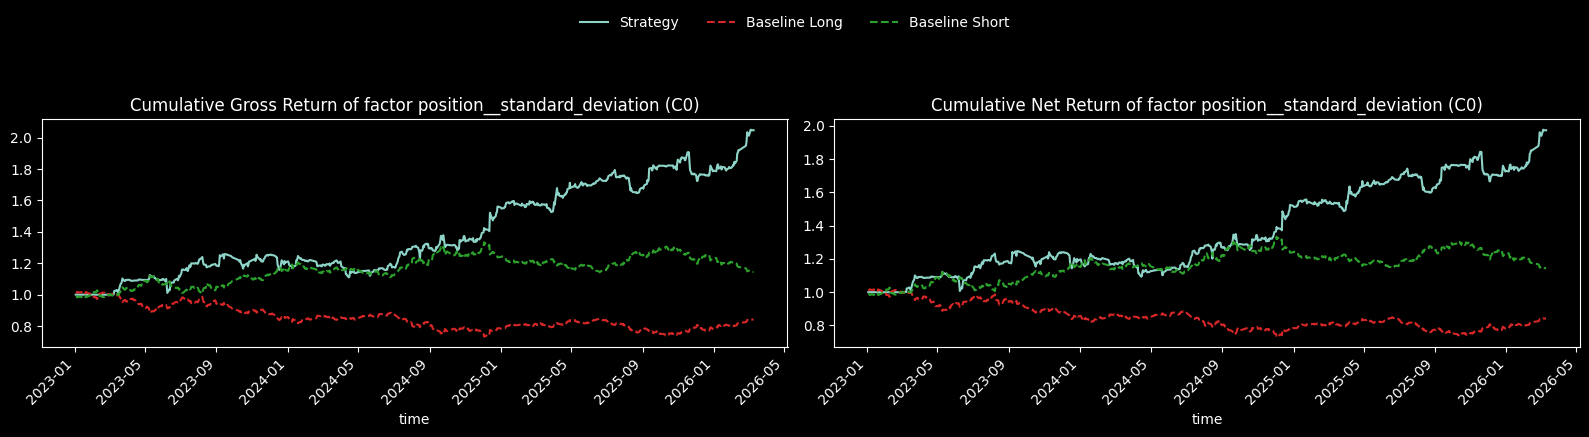

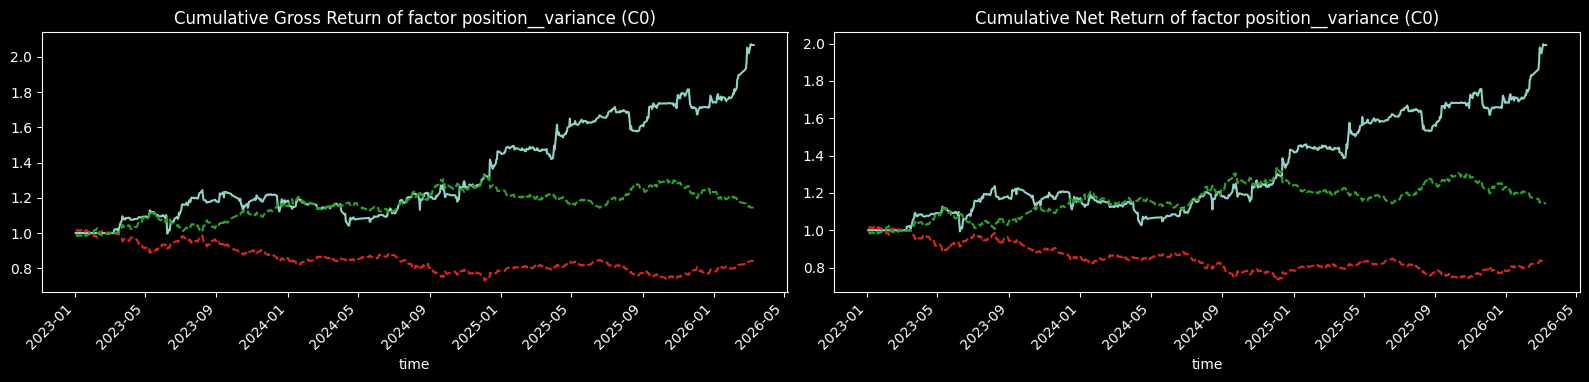

In [21]:
# 全部生成的因子
print("全部生成的因子: ", fg.generated_fc_name_list)
print("选中的因子: ", result['selected_fc_name_list'])
print("计算出的因子值: ")
display(fg.generated_data.iloc[100:110])
print("选中因子的回测结果: ")
display(result['bt'].performance_summary)
print("选中因子的净值曲线: ")
result['bt'].plot_nav(fc_name=result['selected_fc_name_list'],
                                                 show_baseline=True)

## llm自动生成因子

In [2]:
from factors.factor_auto_search import FactorGenerator
fg = FactorGenerator(
    method='llm_prompt',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    max_factor_count=10,
    min_window_size=20,
    model_name='deepseek',
    llm_factor_count=5,
    llm_temperature=0.7,
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20,
    calculate_baseline=True
)

In [5]:
# one-step: mine + filter + save high-quality config
result = fg.auto_mine_select_and_save_fc(
    net_ret_threshold=0.0,
    sharpe_threshold=0.0,
    require_all_instruments=False
)


KeyboardInterrupt: 

In [6]:
result['bt'].performance_summary.columns

Index(['Gross Return', 'Net Return', 'Gross Volatility', 'Net Volatility',
       'Gross Sharpe', 'Net Sharpe', 'Gross Sortino', 'Net Sortino',
       'Gross MaxDD', 'Net MaxDD', 'Gross Calmar', 'Net Calmar',
       'Gross Win Rate', 'Net Win Rate', 'Turnover', 'TS IC', 'TS RankIC',
       'T-corr', 'count', 'all', 'Gross Return (With Baseline)',
       'Net Return (With Baseline)', 'Gross Volatility (With Baseline)',
       'Net Volatility (With Baseline)', 'Gross Sharpe (With Baseline)',
       'Net Sharpe (With Baseline)', 'Gross Sortino (With Baseline)',
       'Net Sortino (With Baseline)', 'Gross MaxDD (With Baseline)',
       'Net MaxDD (With Baseline)', 'Gross Calmar (With Baseline)',
       'Net Calmar (With Baseline)', 'Gross Win Rate (With Baseline)',
       'Net Win Rate (With Baseline)', 'Turnover (With Baseline)',
       'Factor Name', 'Factor Freq', 'Fee', 'Instrument ID'],
      dtype='object')

In [7]:
result['bt'].performance_summary['Gross Return (With Baseline)']

year
2023        -0.0101159(-0.162074,0.177979)
2024       -0.0465398(-0.087511,0.0798167)
2025    0.250496(-8.88178e-16,-0.00953509)
2026          -0.024991(0.573834,-0.36945)
all        0.0534259(-0.0550328,0.0453413)
                       ...                
2023         0.0787067(-0.162074,0.177979)
2024        0.0597903(-0.087511,0.0798167)
2025    0.056626(-8.88178e-16,-0.00953509)
2026          0.0822883(0.573834,-0.36945)
all        0.0657408(-0.0550328,0.0453413)
Name: Gross Return (With Baseline), Length: 150, dtype: object

In [9]:
result.keys()

dict_keys(['config_path', 'selected_fc_name_list', 'bt'])

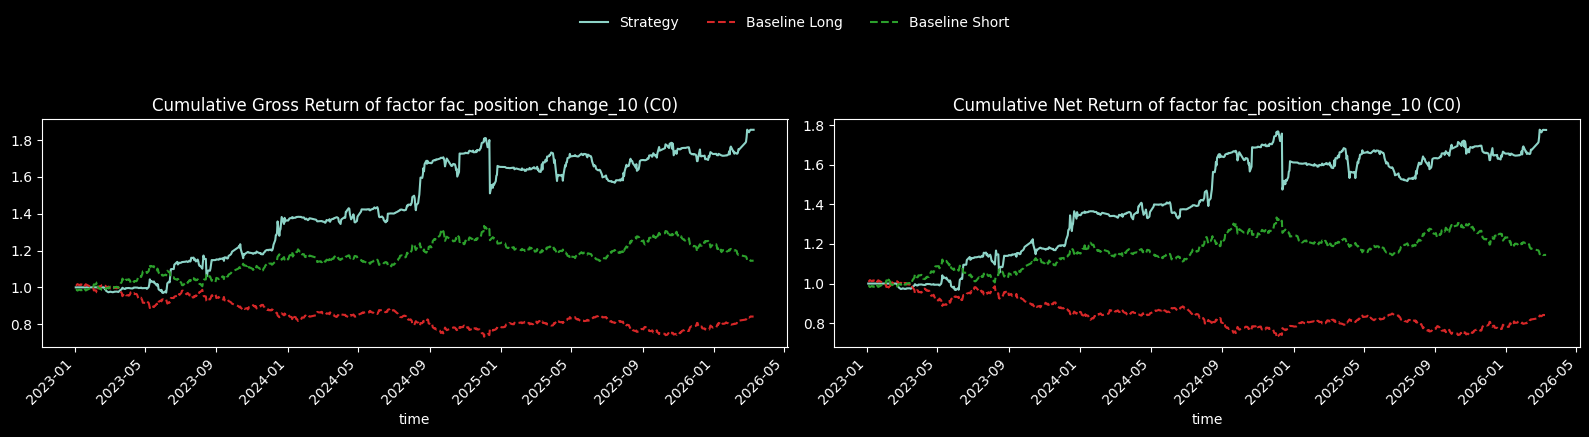

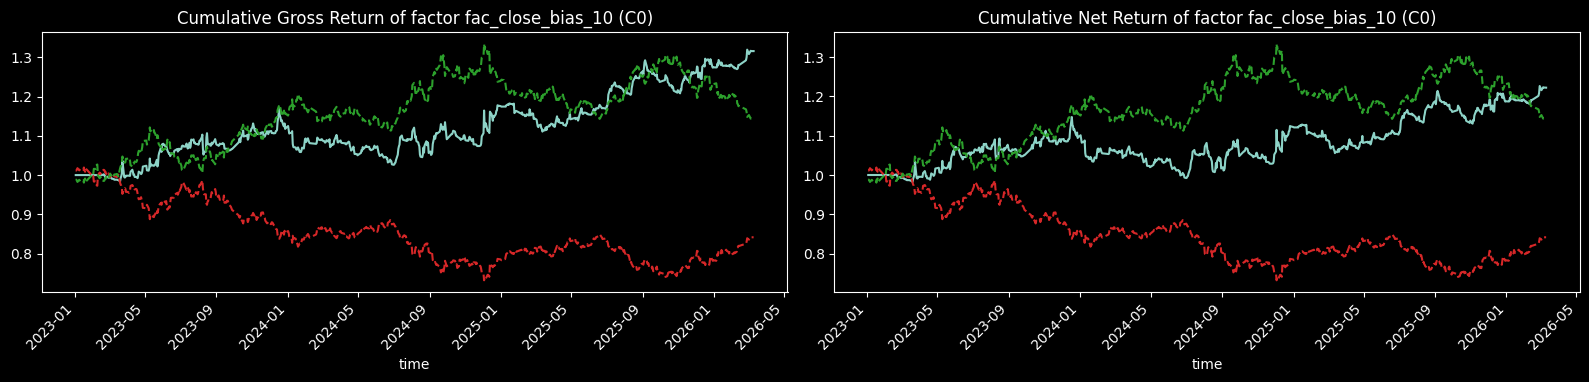

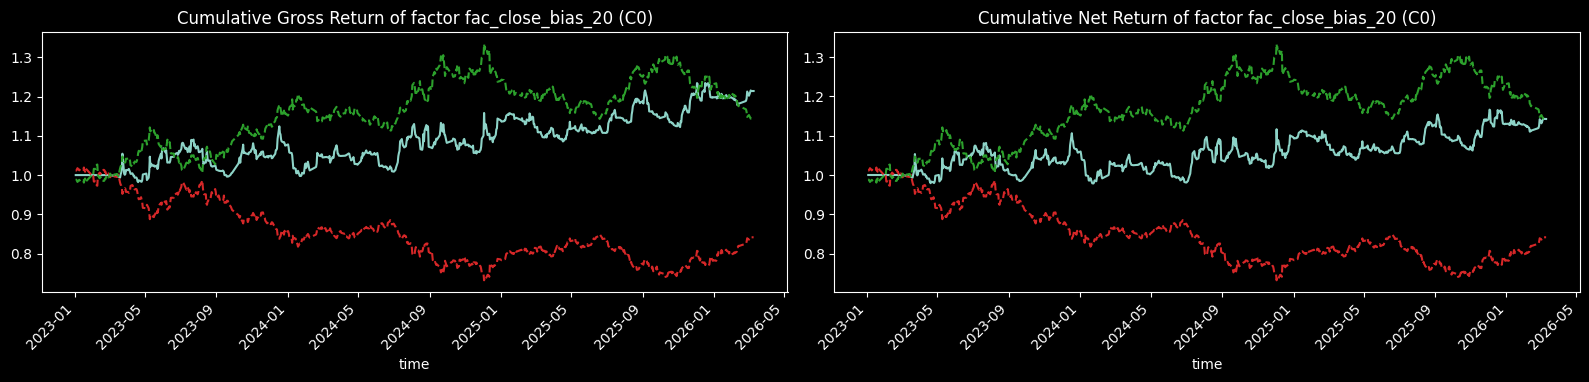

In [14]:
result['bt'].plot_nav(fc_name = result['selected_fc_name_list'],
                      show_baseline=True)